# ML2-Supervised

## 1. Answer the questions
- Derive an analytical solution to the regression problem. Use a vector form of the equation.

$$
w = (X^T X)^{-1}X^T y
$$


- What changes in the solution when L1 and L2 regularizations are added to the loss function.

$$
\min_{\omega} \sum_{i=1}^{N} L\left(f(x_i,\omega), y_i\right) + \lambda R(\omega)
$$

- Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?

$$
R(w) = \sum_{j=1}^{d} |w_j| = \|w\|_1
$$
 L1 regularization adds a penalty proportional to the absolute values of the coefficients. Unlike L2, its shrinkage does not vanish as a coefficient approaches zero, and because the L1 penalty has a non-differentiable point at zero, the optimum often occurs exactly at \(w_j=0\). A zero coefficient means that the corresponding feature does not contribute to the prediction, so L1 produces sparse models and can be used for feature selection.


- Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.

You can fit nonlinear dependencies with the same linear models by transforming the original features into nonlinear features.

## 2. Introduction

### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from itertools import combinations_with_replacement

color = sns.color_palette()

In [2]:
train_df = pd.read_json("../datasets/train.json")
train_df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [3]:
test_df = pd.read_json("../datasets/test.json")
print("Train rows: ", train_df.shape[0])
print("Test rows: ", test_df.shape[0])
test_df.head()

Train rows:  49352
Test rows:  74659


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place


In [4]:
display(train_df.info())
display(test_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  object 
 3   created          74659 non-null  object 
 4   description      74659 non-null  object 
 5   display_address  74659 non-null  object 
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  object 
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 8.5+ MB


None

<Axes: >

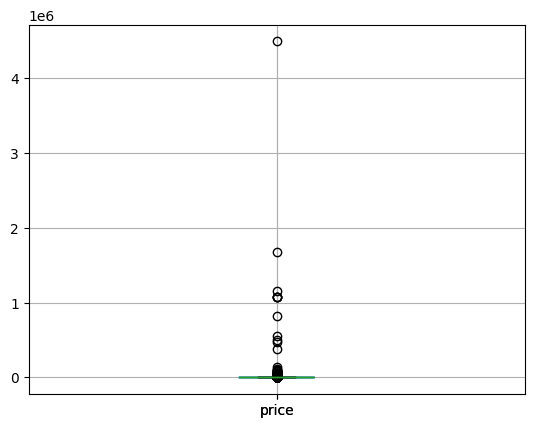

In [5]:
train_df[["price"]].boxplot()
test_df[["price"]].boxplot()

## 3. Intro data analysis part 2

In [6]:
all_features = []

train_df["features"] = train_df["features"].apply(
    lambda values: {value.replace(" ", "") for value in values}
)
test_df["features"] = test_df["features"].apply(
    lambda values: {value.replace(" ", "") for value in values}
)

for feature in train_df["features"]:
    all_features += feature
print(len(set(all_features)))

feature_counts = Counter(all_features)
top_20_features = [feature for feature, count in feature_counts.most_common(20)]
display(pd.DataFrame(feature_counts.most_common(20)))

1548


,0,1
0,Elevator,25915
1,CatsAllowed,23540
2,HardwoodFloors,23527
3,DogsAllowed,22035
4,Doorman,20898
5,Dishwasher,20426
6,NoFee,18062
7,LaundryinBuilding,16344
8,FitnessCenter,13252
9,Pre-War,9148


In [7]:
feature_list = top_20_features + ["bathrooms", "bedrooms"]
for feature in top_20_features:
    train_df[feature] = train_df["features"].apply(
        lambda apartment_features: int(feature in apartment_features)
    )
    test_df[feature] = test_df["features"].apply(
        lambda apartment_features: int(feature in apartment_features)
    )

display(train_df.head())
display(test_df.head())

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"{LaundryinBuilding, Dishwasher, DogsAllowed, D...",40.7108,7170325,-73.9539,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"{Elevator, LaundryinBuilding, Dishwasher, Door...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"{Elevator, LaundryinBuilding, Dishwasher, Door...",40.7575,7158677,-73.9625,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,{},40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"{Elevator, LaundryinBuilding, FitnessCenter, D...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"{Elevator, LaundryinBuilding, Dishwasher, Laun...",40.7185,7142618,-73.9865,...,1,0,1,0,0,0,0,0,0,0
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"{DogsAllowed, CatsAllowed, Pre-War}",40.7278,7210040,-74.0000,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"{DogsAllowed, CatsAllowed, Pre-War}",40.7260,7174566,-74.0026,...,0,0,0,0,0,0,0,0,0,0
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"{DogsAllowed, CatsAllowed, HardwoodFloors}",40.7321,7191391,-74.0028,...,0,0,0,0,0,0,0,0,0,0
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"{Elevator, LaundryinBuilding, DogsAllowed, Doo...",40.7054,7171695,-74.0095,...,0,1,0,0,1,0,0,0,0,0


In [8]:
X_train = train_df[feature_list]
y_train = train_df["price"]

mask = y_train.between(y_train.quantile(0.01), y_train.quantile(0.99))
X_train_filtered = X_train.loc[mask]
y_train_filtered = y_train.loc[mask]

In [9]:
print(mask.value_counts())
print(X_train_filtered.shape)
print(y_train_filtered.shape)

price
True     48379
False      973
Name: count, dtype: int64
(48379, 22)
(48379,)


In [10]:
X_test = test_df[feature_list]
y_test = test_df["price"]

## 4. Models implementation — Linear regression

In [11]:
class Custom_Standard_scaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.scale_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.scale_ = np.where(self.std_ == 0, 1.0, self.std_)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class Custom_MinMax_scaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None
        self.range_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        self.range_ = np.where(self.max_ - self.min_ == 0, 1.0, self.max_ - self.min_)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class Custom_PolynomialFeatures:
    def __init__(self, degree=2, include_bias=False):
        self.degree = degree
        self.include_bias = include_bias
        self.combinations_ = None
        self.n_features = None

    def _validate_params(self, X):
        if X.ndim != 2:
            raise IndexError("Invalid shape datasets")
        if not isinstance(self.degree, (int, np.integer)) or self.degree < 1:
            raise ValueError("degree must be a positive integer")

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self._validate_params(X)
        self.combinations_ = []

        self.n_features = X.shape[1]

        for feature in range(1, self.degree + 1):
            self.combinations_.extend(
                list(combinations_with_replacement(range(self.n_features), feature))
            )

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        self._validate_params(X)

        if self.combinations_ is None:
            raise RuntimeError("Transformer is not fitted")

        if X.shape[1] != self.n_features:
            raise ValueError("Unexpected number of features")

        columns = []

        if self.include_bias:
            columns.append(np.ones(X.shape[0]))

        for combination in self.combinations_:
            columns.append(np.prod(X[:, combination], axis=1))

        return np.column_stack(columns)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class Custom_linear_regression:
    def __init__(
        self,
        method="sgd",
        learning_rate=0.01,
        max_iter=1000,
        random_state=21,
        penalty=None,
        alpha=0.1,
        l1_ratio=0.5,
        tol=1e-6,
        patience=5,
    ) -> None:
        self.method = method
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.weights = None
        self.bias = None
        self.results = []
        self.tol = tol
        self.patience = patience
        self.loss_history_ = []
        self.n_iter_ = 0
        self._validate_param()

    def _validate_param(self):
        if self.alpha < 0:
            raise ValueError("Invalid alpha param")

        if self.l1_ratio > 1 or self.l1_ratio < 0:
            raise ValueError("Invalid l1_ratio param")

        if self.penalty not in (None, "l1", "l2", "elastic"):
            raise ValueError("Invalid penalty param")

        if self.method not in ("sgd", "bgd", "anl"):
            raise ValueError("Choose method gd: sgd, bgd, or anl")

        if not isinstance(self.patience, (int, np.integer)) or self.patience <= 0:
            raise ValueError("Invalid patience param")

        if (
            not isinstance(self.tol, (int, float, np.integer, np.floating))
            or self.tol < 0
        ):
            raise ValueError("Invalid tol param")

        if (
            not isinstance(self.learning_rate, (int, float, np.integer, np.floating))
            or self.learning_rate <= 0
        ):
            raise ValueError("Invalid learning_rate param")

        if not isinstance(self.max_iter, (int, np.integer)) or self.max_iter <= 0:
            raise ValueError("Invalid max_iter param")

    def _penalty_calc(self):
        if self.penalty == "l1":
            return self.alpha * np.sum(np.abs(self.weights))

        elif self.penalty == "l2":
            return self.alpha * np.sum(np.square(self.weights))

        elif self.penalty == "elastic":
            return self.alpha * (
                self.l1_ratio * np.sum(np.abs(self.weights))
                + (1 - self.l1_ratio) * np.sum(np.square(self.weights))
            )

        else:
            return 0.0

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        epochs_without_improvement = 0
        self.loss_history_ = []
        self.n_iter_ = 0
        initial_predictions = X @ self.weights + self.bias
        best_loss = (
            np.mean(np.square(initial_predictions - y)) / 2 + self._penalty_calc()
        )

        best_weights = self.weights.copy()
        best_bias = self.bias

        self.loss_history_ = [best_loss]

        if self.method == "sgd":
            for epoch in range(self.max_iter):
                indices = rng.permutation(n_samples)
                for i in indices:
                    y_pred = X[i] @ self.weights + self.bias
                    error = y_pred - y[i]

                    if self.penalty == "l1":
                        self.weights -= self.learning_rate * (
                            error * X[i] + self.alpha * np.sign(self.weights)
                        )

                    elif self.penalty == "l2":
                        self.weights -= self.learning_rate * (
                            error * X[i] + 2 * self.alpha * self.weights
                        )

                    elif self.penalty == "elastic":
                        self.weights -= self.learning_rate * (
                            error * X[i]
                            + self.alpha
                            * (
                                self.l1_ratio * np.sign(self.weights)
                                + (1 - self.l1_ratio) * 2 * self.weights
                            )
                        )

                    else:
                        self.weights -= self.learning_rate * error * X[i]
                    self.bias -= self.learning_rate * error

                epoch_predictions = X @ self.weights + self.bias
                mse_loss = np.mean(np.square(epoch_predictions - y)) / 2
                penalty_loss = self._penalty_calc()
                current_loss = mse_loss + penalty_loss
                self.loss_history_.append(current_loss)

                if not np.isfinite(current_loss):
                    raise FloatingPointError(
                        "Loss became inf or nan; reduce learning_rate"
                    )

                improvement = best_loss - current_loss
                threshold = self.tol * max(1.0, abs(best_loss))
                improved = improvement > threshold

                if improved:
                    best_loss = current_loss
                    best_weights = self.weights.copy()
                    best_bias = self.bias
                    epochs_without_improvement = 0

                else:
                    epochs_without_improvement += 1

                self.n_iter_ = epoch + 1

                if epochs_without_improvement >= self.patience:
                    break

            if best_weights is not None:
                self.weights = best_weights
                self.bias = best_bias

        elif self.method == "bgd":
            for epoch in range(self.max_iter):
                y_pred = X @ self.weights + self.bias
                error = y_pred - y

                dw = (X.T @ error) / n_samples

                if self.penalty == "l1":
                    dw += self.alpha * np.sign(self.weights)

                elif self.penalty == "l2":
                    dw += 2 * self.alpha * self.weights

                elif self.penalty == "elastic":
                    dw += self.alpha * (
                        self.l1_ratio * np.sign(self.weights)
                        + (1 - self.l1_ratio) * 2 * self.weights
                    )

                db = np.mean(error)

                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

                epoch_predictions = X @ self.weights + self.bias
                mse_loss = np.mean(np.square(epoch_predictions - y)) / 2
                penalty_loss = self._penalty_calc()
                current_loss = mse_loss + penalty_loss
                self.loss_history_.append(current_loss)

                if not np.isfinite(current_loss):
                    raise FloatingPointError(
                        "Loss became inf or nan; reduce learning_rate"
                    )

                improvement = best_loss - current_loss
                threshold = self.tol * max(1.0, abs(best_loss))
                improved = improvement > threshold

                if improved:
                    best_loss = current_loss
                    best_weights = self.weights.copy()
                    best_bias = self.bias
                    epochs_without_improvement = 0

                else:
                    epochs_without_improvement += 1

                self.n_iter_ = epoch + 1

                if epochs_without_improvement >= self.patience:
                    break

            if best_weights is not None:
                self.weights = best_weights
                self.bias = best_bias

        elif self.method == "anl":
            X_bias = np.c_[np.ones(X.shape[0]), X]
            theta = []

            if self.penalty == "l1":
                raise ValueError("analytical gradient descent didn`t have l1 solve")

            elif self.penalty == "l2":
                reg_matrix = np.eye(n_features + 1)
                reg_matrix[0, 0] = 0
                theta = np.linalg.solve(
                    X_bias.T @ X_bias + 2 * n_samples * self.alpha * reg_matrix,
                    X_bias.T @ y,
                )

            elif self.penalty == "elastic":
                if self.l1_ratio == 0:
                    reg_matrix = np.eye(n_features + 1)
                    reg_matrix[0, 0] = 0
                    theta = np.linalg.solve(
                        X_bias.T @ X_bias + 2 * n_samples * self.alpha * reg_matrix,
                        X_bias.T @ y,
                    )
                else:
                    raise ValueError("analytical gradient descent didn`t have l1 solve")

            else:
                theta = np.linalg.lstsq(X_bias, y, rcond=None)
                theta = theta[0]

            self.bias = theta[0]
            self.weights = theta[1:]

        return self

    def predict(self, X):
        return X @ self.weights + self.bias


class ModelEvaluator:
    def __init__(
        self,
        model,
        regularization=None,
        scaler=None,
        poly=None,
        X_train=X_train_filtered,
        y_train=y_train_filtered,
        X_test=X_test,
        y_test=y_test,
        log_target=False,
    ):
        self.model = model
        self.model_name = getattr(model, "method", model.__class__.__name__)
        self.reg = regularization
        self.scaler = scaler
        self.poly = poly
        self.x_train = X_train
        self.y_train = y_train
        self.x_test = X_test
        self.y_test = y_test
        self.log_target = log_target

    def fit(self):
        x_train = np.asarray(self.x_train, dtype=float)
        x_test = np.asarray(self.x_test, dtype=float)

        if self.poly is not None:
            x_train = self.poly.fit_transform(x_train)
            x_test = self.poly.transform(x_test)

        if self.scaler is not None:
            x_train = self.scaler.fit_transform(x_train)
            x_test = self.scaler.transform(x_test)

        self.x_train_transformed = x_train
        self.x_test_transformed = x_test

        target = np.log1p(self.y_train) if self.log_target else self.y_train

        self.model.fit(self.x_train_transformed, target)
        return self

    def predict(self):

        self.y_train_predict = self.model.predict(self.x_train_transformed)
        self.y_test_predict = self.model.predict(self.x_test_transformed)

        if self.log_target:
            self.y_train_predict = np.expm1(self.y_train_predict)
            self.y_test_predict = np.expm1(self.y_test_predict)

        return self

    def _formula(self, y_true, y_pred):
        ssr = np.sum(np.square(y_true - y_pred))
        sst = np.sum(np.square(y_true - y_true.mean()))
        if np.isclose(sst, 0) and np.isclose(ssr, 0):
            return 1

        elif np.isclose(sst, 0):
            return 0

        else:
            return round(float(1 - ssr / sst), 3)

    def metrics(self):

        mae_df = pd.DataFrame([
            {
                "model": self.model_name,
                "regularization": getattr(self.model, "penalty", self.reg),
                "alpha": getattr(self.model, "alpha", None)
                if self.reg is not None
                else None,
                "feature_set": "poly" if self.poly is not None else "base",
                "poly_degree": getattr(self.poly, "degree", None),
                "target_transform": "log1p" if self.log_target else "None",
                "scaler": self.scaler.__class__.__name__
                if self.scaler is not None
                else "None",
                "train": round(
                    float(abs(self.y_train - self.y_train_predict).mean()), 3
                ),
                "test": round(float(abs(self.y_test - self.y_test_predict).mean()), 3),
            }
        ])

        rmse_df = pd.DataFrame([
            {
                "model": self.model_name,
                "regularization": getattr(self.model, "penalty", self.reg),
                "alpha": getattr(self.model, "alpha", None),
                "feature_set": "poly" if self.poly is not None else "base",
                "poly_degree": getattr(self.poly, "degree", None),
                "target_transform": "log1p" if self.log_target else "None",
                "scaler": self.scaler.__class__.__name__
                if self.scaler is not None
                else "None",
                "train": round(
                    float(
                        np.sqrt(np.square(self.y_train - self.y_train_predict).mean())
                    ),
                    3,
                ),
                "test": round(
                    float(np.sqrt(np.square(self.y_test - self.y_test_predict).mean())),
                    3,
                ),
            }
        ])

        r2_df = pd.DataFrame([
            {
                "model": self.model_name,
                "regularization": getattr(self.model, "penalty", self.reg),
                "alpha": getattr(self.model, "alpha", None),
                "feature_set": "poly" if self.poly is not None else "base",
                "poly_degree": getattr(self.poly, "degree", None),
                "target_transform": "log1p" if self.log_target else "None",
                "scaler": self.scaler.__class__.__name__
                if self.scaler is not None
                else "None",
                "train": self._formula(self.y_train, self.y_train_predict),
                "test": self._formula(self.y_test, self.y_test_predict),
            }
        ])

        return {"MAE": mae_df, "RMSE": rmse_df, "R2": r2_df}

In [12]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

In [13]:
frames = [
    ModelEvaluator(Custom_linear_regression("sgd")).fit().predict().metrics(),
    ModelEvaluator(LinearRegression()).fit().predict().metrics(),
]

In [14]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
base_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in base_frames.items():
    print(metric_name)
    display(table)

MAE


/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_8918/1681765425.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metric_name: pd.concat(frames, ignore_index=True)


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,None,base,None,None,None,711.849,908.343
1,LinearRegression,None,None,base,None,None,None,711.791,909.886


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,base,None,None,None,1046.859,9608.397
1,LinearRegression,None,NaN,base,None,None,None,1035.352,9603.903


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,base,None,None,None,0.571,0.021
1,LinearRegression,None,NaN,base,None,None,None,0.580,0.022


## 5. Regularized models implementation — Ridge, Lasso, ElasticNet

In [15]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

In [16]:
frames = [
    ModelEvaluator(Custom_linear_regression("sgd", penalty="l1", alpha=0.5))
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Custom_linear_regression("sgd", penalty="l2", alpha=0.5))
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Custom_linear_regression("sgd", penalty="elastic", alpha=0.5))
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Lasso(alpha=0.5), regularization="l1").fit().predict().metrics(),
    ModelEvaluator(Ridge(alpha=0.5), regularization="l2").fit().predict().metrics(),
    ModelEvaluator(ElasticNet(alpha=0.5), regularization="elastic")
    .fit()
    .predict()
    .metrics(),
]

In [17]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
regularized_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in regularized_frames.items():
    print(metric_name)
    display(table)

MAE


/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_8918/1322578033.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metric_name: pd.concat(frames, ignore_index=True)


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,l1,NaN,base,None,None,None,711.757,908.291
1,sgd,l2,NaN,base,None,None,None,855.453,1079.925
2,sgd,elastic,NaN,base,None,None,None,795.297,1015.268
3,Lasso,l1,0.5,base,None,None,None,711.544,909.724
4,Ridge,l2,0.5,base,None,None,None,711.790,909.886
5,ElasticNet,elastic,0.5,base,None,None,None,762.825,976.096


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,l1,0.5,base,None,None,None,1046.869,9608.487
1,sgd,l2,0.5,base,None,None,None,1278.678,9651.497
2,sgd,elastic,0.5,base,None,None,None,1210.394,9637.783
3,Lasso,l1,0.5,base,None,None,None,1035.401,9604.040
4,Ridge,l2,0.5,base,None,None,None,1035.352,9603.902
5,ElasticNet,elastic,0.5,base,None,None,None,1127.268,9618.258


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,l1,0.5,base,None,None,None,0.571,0.021
1,sgd,l2,0.5,base,None,None,None,0.359,0.013
2,sgd,elastic,0.5,base,None,None,None,0.426,0.015
3,Lasso,l1,0.5,base,None,None,None,0.580,0.022
4,Ridge,l2,0.5,base,None,None,None,0.580,0.022
5,ElasticNet,elastic,0.5,base,None,None,None,0.502,0.019


## 6. Feature normalization

In [18]:
model_custom = Custom_MinMax_scaler()
model = MinMaxScaler()

X_train_transform_custom = model_custom.fit_transform(X_train_filtered)
X_train_transform = model.fit_transform(X_train_filtered)
print(np.allclose(X_train_transform_custom, X_train_transform))

X_test_transform_custom = model_custom.transform(X_test)
X_test_transform = model.transform(X_test)
print(np.allclose(X_test_transform_custom, X_test_transform))

model_custom = Custom_Standard_scaler()
model = StandardScaler()

X_train_transform_custom = model_custom.fit_transform(X_train_filtered)
X_train_transform = model.fit_transform(X_train_filtered)
print(np.allclose(X_train_transform_custom, X_train_transform))

X_test_transform_custom = model_custom.transform(X_test)
X_test_transform = model.transform(X_test)
print(np.allclose(X_test_transform_custom, X_test_transform))

True
True
True
True


## 7. Fit custom and sklearn models with normalized data

In [19]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

In [20]:
frames = [
    ModelEvaluator(Custom_linear_regression("sgd"), scaler=Custom_MinMax_scaler())
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="l1", alpha=0.5),
        scaler=Custom_MinMax_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="l2", alpha=0.5),
        scaler=Custom_MinMax_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="elastic", alpha=0.5),
        scaler=Custom_MinMax_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Custom_linear_regression("sgd"), scaler=Custom_Standard_scaler())
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="l1", alpha=0.5),
        scaler=Custom_Standard_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="l2", alpha=0.5),
        scaler=Custom_Standard_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression("sgd", penalty="elastic", alpha=0.5),
        scaler=Custom_Standard_scaler(),
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(LinearRegression(), scaler=MinMaxScaler()).fit().predict().metrics(),
    ModelEvaluator(Lasso(), scaler=MinMaxScaler(), regularization="l1")
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Ridge(), scaler=MinMaxScaler(), regularization="l2")
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(ElasticNet(), scaler=MinMaxScaler(), regularization="elastic")
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(LinearRegression(), scaler=StandardScaler())
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Lasso(), scaler=StandardScaler(), regularization="l1")
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(Ridge(), scaler=StandardScaler(), regularization="l2")
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(ElasticNet(), scaler=StandardScaler(), regularization="elastic")
    .fit()
    .predict()
    .metrics(),
]

In [21]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
scaled_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in scaled_frames.items():
    print(metric_name)
    display(table)

MAE


/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_8918/2256808374.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metric_name: pd.concat(frames, ignore_index=True)


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,NaN,base,None,None,Custom_MinMax_scaler,729.414,925.418
1,sgd,l1,NaN,base,None,None,Custom_MinMax_scaler,728.819,925.301
2,sgd,l2,NaN,base,None,None,Custom_MinMax_scaler,1097.422,1328.187
3,sgd,elastic,NaN,base,None,None,Custom_MinMax_scaler,1065.973,1297.511
4,sgd,None,NaN,base,None,None,Custom_Standard_scaler,719.617,918.174
5,sgd,l1,NaN,base,None,None,Custom_Standard_scaler,719.452,918.041
6,sgd,l2,NaN,base,None,None,Custom_Standard_scaler,771.907,982.444
7,sgd,elastic,NaN,base,None,None,Custom_Standard_scaler,737.666,943.853
8,LinearRegression,None,NaN,base,None,None,MinMaxScaler,711.791,909.886
9,Lasso,l1,1.0,base,None,None,MinMaxScaler,711.650,910.535


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,base,None,None,Custom_MinMax_scaler,1040.772,9602.637
1,sgd,l1,0.5,base,None,None,Custom_MinMax_scaler,1040.526,9602.472
2,sgd,l2,0.5,base,None,None,Custom_MinMax_scaler,1522.099,9698.539
3,sgd,elastic,0.5,base,None,None,Custom_MinMax_scaler,1500.700,9694.060
4,sgd,None,0.1,base,None,None,Custom_Standard_scaler,1060.036,9612.256
5,sgd,l1,0.5,base,None,None,Custom_Standard_scaler,1059.959,9612.262
6,sgd,l2,0.5,base,None,None,Custom_Standard_scaler,1126.643,9619.669
7,sgd,elastic,0.5,base,None,None,Custom_Standard_scaler,1085.302,9613.351
8,LinearRegression,None,NaN,base,None,None,MinMaxScaler,1035.352,9603.903
9,Lasso,l1,1.0,base,None,None,MinMaxScaler,1035.776,9603.639


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,base,None,None,Custom_MinMax_scaler,0.576,0.023
1,sgd,l1,0.5,base,None,None,Custom_MinMax_scaler,0.576,0.023
2,sgd,l2,0.5,base,None,None,Custom_MinMax_scaler,0.092,0.003
3,sgd,elastic,0.5,base,None,None,Custom_MinMax_scaler,0.118,0.004
4,sgd,None,0.1,base,None,None,Custom_Standard_scaler,0.560,0.021
5,sgd,l1,0.5,base,None,None,Custom_Standard_scaler,0.560,0.021
6,sgd,l2,0.5,base,None,None,Custom_Standard_scaler,0.503,0.019
7,sgd,elastic,0.5,base,None,None,Custom_Standard_scaler,0.539,0.020
8,LinearRegression,None,NaN,base,None,None,MinMaxScaler,0.580,0.022
9,Lasso,l1,1.0,base,None,None,MinMaxScaler,0.580,0.022


## 8. Overfit models

In [22]:
poly_source_columns = ["bathrooms", "bedrooms"]
poly_upper_bounds = X_train_filtered[poly_source_columns].quantile(0.999)

poly_source_train = X_train_filtered[poly_source_columns].copy()
poly_source_test = X_test[poly_source_columns].copy()

poly_source_train = poly_source_train.clip(upper=poly_upper_bounds, axis=1)
poly_source_test = poly_source_test.clip(upper=poly_upper_bounds, axis=1)

poly_shape_check = Custom_PolynomialFeatures(
    degree=10, include_bias=False
).fit_transform(poly_source_train)

print(poly_shape_check.shape)

(48379, 65)


In [23]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

In [24]:
alphas = [0.001, 0.01, 0.1, 0.5, 1, 10]
frames = []
frames.append(
    ModelEvaluator(
        Custom_linear_regression("sgd", learning_rate=1e-6, max_iter=90),
        scaler=Custom_Standard_scaler(),
        poly=Custom_PolynomialFeatures(degree=10, include_bias=False),
        X_train=poly_source_train,
        X_test=poly_source_test,
    )
    .fit()
    .predict()
    .metrics()
)

for alpha in alphas:
    frames.append(
        ModelEvaluator(
            Custom_linear_regression(
                "sgd", learning_rate=1e-6, penalty="l1", alpha=alpha, max_iter=90
            ),
            scaler=Custom_Standard_scaler(),
            poly=Custom_PolynomialFeatures(degree=10, include_bias=False),
            X_train=poly_source_train,
            X_test=poly_source_test,
        )
        .fit()
        .predict()
        .metrics()
    )
    frames.append(
        ModelEvaluator(
            Custom_linear_regression(
                "sgd", learning_rate=1e-6, penalty="l2", alpha=alpha, max_iter=90
            ),
            scaler=Custom_Standard_scaler(),
            poly=Custom_PolynomialFeatures(degree=10, include_bias=False),
            X_train=poly_source_train,
            X_test=poly_source_test,
        )
        .fit()
        .predict()
        .metrics()
    )
    frames.append(
        ModelEvaluator(
            Custom_linear_regression(
                "sgd", learning_rate=1e-6, penalty="elastic", alpha=alpha, max_iter=90
            ),
            scaler=Custom_Standard_scaler(),
            poly=Custom_PolynomialFeatures(degree=10, include_bias=False),
            X_train=poly_source_train,
            X_test=poly_source_test,
        )
        .fit()
        .predict()
        .metrics()
    )

KeyboardInterrupt: 

In [ ]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
polynomial_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in polynomial_frames.items():
    print(metric_name)
    display(table)

MAE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,None,poly,10,None,Custom_Standard_scaler,769.675,966.753
1,sgd,l1,None,poly,10,None,Custom_Standard_scaler,769.675,966.753
2,sgd,l2,None,poly,10,None,Custom_Standard_scaler,769.696,966.771
3,sgd,elastic,None,poly,10,None,Custom_Standard_scaler,769.685,966.762
4,sgd,l1,None,poly,10,None,Custom_Standard_scaler,769.676,966.753
5,sgd,l2,None,poly,10,None,Custom_Standard_scaler,769.891,966.942
6,sgd,elastic,None,poly,10,None,Custom_Standard_scaler,769.782,966.846
7,sgd,l1,None,poly,10,None,Custom_Standard_scaler,769.684,966.757
8,sgd,l2,None,poly,10,None,Custom_Standard_scaler,773.200,970.228
9,sgd,elastic,None,poly,10,None,Custom_Standard_scaler,771.297,968.286


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.100,poly,10,None,Custom_Standard_scaler,1104.084,9593.480
1,sgd,l1,0.001,poly,10,None,Custom_Standard_scaler,1104.084,9593.480
2,sgd,l2,0.001,poly,10,None,Custom_Standard_scaler,1104.136,9593.470
3,sgd,elastic,0.001,poly,10,None,Custom_Standard_scaler,1104.110,9593.475
4,sgd,l1,0.010,poly,10,None,Custom_Standard_scaler,1104.087,9593.479
5,sgd,l2,0.010,poly,10,None,Custom_Standard_scaler,1104.613,9593.385
6,sgd,elastic,0.010,poly,10,None,Custom_Standard_scaler,1104.346,9593.430
7,sgd,l1,0.100,poly,10,None,Custom_Standard_scaler,1104.109,9593.468
8,sgd,l2,0.100,poly,10,None,Custom_Standard_scaler,1110.053,9592.952
9,sgd,elastic,0.100,poly,10,None,Custom_Standard_scaler,1106.943,9593.108


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.100,poly,10,None,Custom_Standard_scaler,0.522,0.024
1,sgd,l1,0.001,poly,10,None,Custom_Standard_scaler,0.522,0.024
2,sgd,l2,0.001,poly,10,None,Custom_Standard_scaler,0.522,0.024
3,sgd,elastic,0.001,poly,10,None,Custom_Standard_scaler,0.522,0.024
4,sgd,l1,0.010,poly,10,None,Custom_Standard_scaler,0.522,0.024
5,sgd,l2,0.010,poly,10,None,Custom_Standard_scaler,0.522,0.024
6,sgd,elastic,0.010,poly,10,None,Custom_Standard_scaler,0.522,0.024
7,sgd,l1,0.100,poly,10,None,Custom_Standard_scaler,0.522,0.024
8,sgd,l2,0.100,poly,10,None,Custom_Standard_scaler,0.517,0.025
9,sgd,elastic,0.100,poly,10,None,Custom_Standard_scaler,0.520,0.025


## 9. Native models

In [ ]:
def formula(y_true, y_pred):
    ssr = np.sum(np.square(y_true - y_pred))
    sst = np.sum(np.square(y_true - y_true.mean()))
    if np.isclose(sst, 0) and np.isclose(ssr, 0):
        return 1

    elif np.isclose(sst, 0):
        return 0

    else:
        return round(float(1 - ssr / sst), 3)


def metric(y_train, y_test, y_pred_train, y_pred_test, model_name):
    mae_df = pd.DataFrame([
        {
            "model": model_name,
            "regularization": None,
            "alpha": None,
            "feature_set": "baseline",
            "scaler": None,
            "train": round(float(abs(y_train - y_pred_train).mean()), 3),
            "test": round(float(abs(y_test - y_pred_test).mean()), 3),
        }
    ])

    rmse_df = pd.DataFrame([
        {
            "model": model_name,
            "regularization": None,
            "alpha": None,
            "feature_set": "baseline",
            "scaler": None,
            "train": round(float(np.sqrt(np.square(y_train - y_pred_train).mean())), 3),
            "test": round(float(np.sqrt(np.square(y_test - y_pred_test).mean())), 3),
        }
    ])

    r2_df = pd.DataFrame([
        {
            "model": model_name,
            "regularization": None,
            "alpha": None,
            "feature_set": "baseline",
            "scaler": None,
            "train": formula(y_train, y_pred_train),
            "test": formula(y_test, y_pred_test),
        }
    ])

    return {"MAE": mae_df, "RMSE": rmse_df, "R2": r2_df}

In [ ]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

In [ ]:
mean_value = y_train_filtered.mean()
median_value = y_train_filtered.median()

mean_train_predict = np.full(len(y_train_filtered), mean_value)
median_train_predict = np.full(len(y_train_filtered), median_value)

mean_test_predict = np.full(len(y_test), mean_value)
median_test_predict = np.full(len(y_test), median_value)

In [ ]:
frames = [
    metric(
        y_train_filtered, y_test, mean_train_predict, mean_test_predict, "Native_mean"
    ),
    metric(
        y_train_filtered,
        y_test,
        median_train_predict,
        median_test_predict,
        "Native_median",
    ),
]

In [ ]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
native_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in native_frames.items():
    print(metric_name)
    display(table)

MAE


,model,regularization,alpha,feature_set,scaler,train,test
0,Native_mean,None,None,baseline,None,1139.193,1374.696
1,Native_median,None,None,baseline,None,1086.211,1322.641


RMSE


,model,regularization,alpha,feature_set,scaler,train,test
0,Native_mean,None,None,baseline,None,1597.647,9715.305
1,Native_median,None,None,baseline,None,1644.236,9731.481


R2


,model,regularization,alpha,feature_set,scaler,train,test
0,Native_mean,None,None,baseline,None,0.000,-0.000
1,Native_median,None,None,baseline,None,-0.059,-0.004


## 10. Compare results

In [ ]:
result_groups = [
    base_frames,
    regularized_frames,
    scaled_frames,
    polynomial_frames,
    native_frames,
]
metric_names = ["MAE", "RMSE", "R2"]

final_tables = {
    metric_name: pd.concat(
        [group[metric_name] for group in result_groups],
        ignore_index=True,
    )
    for metric_name in metric_names
}

for metric_name, table in final_tables.items():
    print(metric_name)
    display(table)

MAE


/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_60070/761779907.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metric_name: pd.concat(
/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_60070/761779907.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metric_name: pd.concat(
/var/folders/2z/wl3835yj3jd8653syy7lktlw0000gn/T/ipykernel_60070/761779907.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future ver

,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,NaN,base,NaN,None,None,711.849,908.343
1,LinearRegression,None,NaN,base,NaN,None,None,711.791,909.886
2,sgd,l1,NaN,base,NaN,None,None,711.757,908.291
3,sgd,l2,NaN,base,NaN,None,None,855.453,1079.925
4,sgd,elastic,NaN,base,NaN,None,None,795.297,1015.268
5,Lasso,l1,0.5,base,NaN,None,None,711.544,909.724
6,Ridge,l2,0.5,base,NaN,None,None,711.790,909.886
7,ElasticNet,elastic,0.5,base,NaN,None,None,762.825,976.096
8,sgd,None,NaN,base,NaN,None,Custom_MinMax_scaler,729.414,925.418
9,sgd,l1,NaN,base,NaN,None,Custom_MinMax_scaler,728.819,925.301


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.100,base,NaN,None,None,1046.859,9608.397
1,LinearRegression,None,NaN,base,NaN,None,None,1035.352,9603.903
2,sgd,l1,0.500,base,NaN,None,None,1046.869,9608.487
3,sgd,l2,0.500,base,NaN,None,None,1278.678,9651.497
4,sgd,elastic,0.500,base,NaN,None,None,1210.394,9637.783
5,Lasso,l1,0.500,base,NaN,None,None,1035.401,9604.040
6,Ridge,l2,0.500,base,NaN,None,None,1035.352,9603.902
7,ElasticNet,elastic,0.500,base,NaN,None,None,1127.268,9618.258
8,sgd,None,0.100,base,NaN,None,Custom_MinMax_scaler,1040.772,9602.637
9,sgd,l1,0.500,base,NaN,None,Custom_MinMax_scaler,1040.526,9602.472


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.100,base,NaN,None,None,0.571,0.021
1,LinearRegression,None,NaN,base,NaN,None,None,0.580,0.022
2,sgd,l1,0.500,base,NaN,None,None,0.571,0.021
3,sgd,l2,0.500,base,NaN,None,None,0.359,0.013
4,sgd,elastic,0.500,base,NaN,None,None,0.426,0.015
5,Lasso,l1,0.500,base,NaN,None,None,0.580,0.022
6,Ridge,l2,0.500,base,NaN,None,None,0.580,0.022
7,ElasticNet,elastic,0.500,base,NaN,None,None,0.502,0.019
8,sgd,None,0.100,base,NaN,None,Custom_MinMax_scaler,0.576,0.023
9,sgd,l1,0.500,base,NaN,None,Custom_MinMax_scaler,0.576,0.023


## 11. Addition task

In [ ]:
metric_tables = {
    "MAE": [],
    "RMSE": [],
    "R2": [],
}

numeric_features = ["bathrooms", "bedrooms"]
clip_upper_bounds = X_train_filtered[numeric_features].quantile(0.999)

X_train_clipped = X_train_filtered.copy()
X_test_clipped = X_test.copy()

X_train_clipped.loc[:, numeric_features] = X_train_clipped[numeric_features].clip(
    upper=clip_upper_bounds, axis=1
)
X_test_clipped.loc[:, numeric_features] = X_test_clipped[numeric_features].clip(
    upper=clip_upper_bounds, axis=1
)

In [ ]:
frames = [
    ModelEvaluator(
        Custom_linear_regression(
            learning_rate=1e-4,
            max_iter=300,
            tol=1e-7,
            patience=10,
        ),
        scaler=Custom_Standard_scaler(),
        poly=Custom_PolynomialFeatures(degree=2, include_bias=False),
        X_train=X_train_clipped,
        X_test=X_test_clipped,
        log_target=False,
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression(
            learning_rate=1e-4,
            max_iter=300,
            tol=1e-7,
            patience=10,
        ),
        scaler=Custom_Standard_scaler(),
        poly=Custom_PolynomialFeatures(degree=2, include_bias=False),
        X_train=X_train_clipped,
        X_test=X_test_clipped,
        log_target=True,
    )
    .fit()
    .predict()
    .metrics(),
    ModelEvaluator(
        Custom_linear_regression(method="anl"),
        scaler=Custom_Standard_scaler(),
        poly=Custom_PolynomialFeatures(degree=2, include_bias=False),
        X_train=X_train_clipped,
        X_test=X_test_clipped,
        log_target=True,
    )
    .fit()
    .predict()
    .metrics(),
]


In [ ]:
for result in frames:
    for metric_name, frame in result.items():
        metric_tables[metric_name].append(frame)
log_frames = {
    metric_name: pd.concat(frames, ignore_index=True)
    for metric_name, frames in metric_tables.items()
}
for metric_name, table in log_frames.items():
    print(metric_name)
    display(table)

MAE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,None,poly,2,None,Custom_Standard_scaler,663.135,847.928
1,sgd,None,None,poly,2,log1p,Custom_Standard_scaler,654.088,829.866
2,anl,None,None,poly,2,log1p,Custom_Standard_scaler,652.913,829.137


RMSE


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,poly,2,None,Custom_Standard_scaler,968.765,9558.924
1,sgd,None,0.1,poly,2,log1p,Custom_Standard_scaler,988.194,9552.207
2,anl,None,0.1,poly,2,log1p,Custom_Standard_scaler,986.711,9552.920


R2


,model,regularization,alpha,feature_set,poly_degree,target_transform,scaler,train,test
0,sgd,None,0.1,poly,2,None,Custom_Standard_scaler,0.632,0.031
1,sgd,None,0.1,poly,2,log1p,Custom_Standard_scaler,0.617,0.033
2,anl,None,0.1,poly,2,log1p,Custom_Standard_scaler,0.619,0.033


Target prices have a right-skewed distribution with a heavy tail: most observations have moderate prices, while a small number of observations have extremely high prices. These values have a strong influence on squared-error-based models. The monotonic log1p transformation preserves the order of target values but compresses large values and reduces skewness. The model is trained on the transformed target, and expm1 is applied to predictions before calculating metrics in the original price scale.

Outliers are removed only from the training sample because training observations directly affect the estimated model coefficients. Extreme values can strongly shift the regression line and make the model unstable. The test sample must remain unchanged because it represents unseen real-world data and is used for an unbiased evaluation. Removing observations based on test target values would cause data leakage and artificially improve the reported metrics. Outlier thresholds must therefore be calculated using training data only.